# SINDy-RL Analysis

Standalone analysis notebook — generates all report figures without re-training.
Estimated runtime: 20–40 minutes (§6 and §7 scan 35 additional checkpoints; §8 adds another pass).

§1–§5 depend only on `sindy-rl.ipynb` outputs and run independently.
§6 requires `sindy-rl-lagrangian.ipynb` results (`results/sindy_rl_lagrangian/ppo_models/`).
§7 requires `sindy-rl-sac.ipynb` results (`results/sindy_rl/sac_models/`).
§8 requires §1, §6, §7 plus all four variant notebooks to have been run.

| § | Title | Dependencies |
|---|---|---|
| 1 | Episode Length Box Plots | `sindy-rl.ipynb` |
| 2 | Feature Matrix Condition Number | `sindy-rl.ipynb` |
| 3 | Distillation Dataset (run before §4, §5) | §1 |
| 4 | Distilled Coefficient Chart | §3 |
| 5 | STLSQ Threshold Ablation | §3 |
| 6 | Library Comparison: degree-3 vs Lagrangian | §2 + `sindy-rl-lagrangian.ipynb` |
| 7 | Algorithm Comparison: PPO vs SAC | §1 + `sindy-rl-sac.ipynb` |
| 8 | All Variants Comparison | §1 + §6 + §7 + all variant notebooks |

In [62]:
import pathlib, warnings, re
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import pysindy as ps
from stable_baselines3 import PPO
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT  = pathlib.Path("/Users/patrick/Documents/personal/UW/ME_595")
DATA_DIR      = PROJECT_ROOT / "data"
RESULTS_DIR   = PROJECT_ROOT / "results" / "sindy_rl"
PPO_MODEL_DIR = RESULTS_DIR / "ppo_models"
DIST_DIR      = DATA_DIR / "distillation"
FIG_DIR       = PROJECT_ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

L1, L2             = 0.6, 0.6
CONV_SUCCESS_STEPS = 500
ACTION_LOW, ACTION_HIGH = -1.0, 1.0
SINDY_DEGREE   = 3
DIST_DEGREE    = 3
DIST_THRESHOLD = 0.1
N_EXPERT       = 50_000
N_PERTURB      = 5
PERTURB_STD    = np.array([0.02, 0.02, 0.02, 0.05, 0.10, 0.10])
N_EVAL_EPISODES = 20
STATE_LABELS    = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]

In [63]:
def obs_to_state6(obs):
    """9-dim MuJoCo obs → state6 [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7]
    ], dtype=np.float64)

def _state6_to_obs8(s6):
    """state6 → obs8 [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        s6[0], np.sin(s6[1]), np.sin(s6[2]),
        np.cos(s6[1]), np.cos(s6[2]),
        s6[3], s6[4], s6[5]
    ], dtype=np.float64)

def action_arr(u):
    return np.array([np.clip(float(u), ACTION_LOW, ACTION_HIGH)], dtype=np.float32)

def evaluate_policy_mujoco(model, n_episodes=N_EVAL_EPISODES, seed=0, use_state6=True):
    """Returns np.array of episode lengths, shape (n_episodes,)."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, ep_len = False, 0
        while not done:
            inp = obs_to_state6(obs).astype(np.float32) if use_state6 else obs.astype(np.float32)
            action, _ = model.predict(inp, deterministic=True)
            obs, _, terminated, truncated, _ = env.step(action_arr(float(action.ravel()[0])))
            done = terminated or truncated
            ep_len += 1
        lengths.append(ep_len)
    env.close()
    return np.array(lengths)

## §1 — Episode Length Box Plots

Quick-scan all sindy-rl checkpoints (3 episodes each) to identify the best iteration,
then full 20-episode evaluation on baseline + a spread of sindy-rl iterations including best.

In [64]:
N_QUICK_SCAN = 3  # episodes per checkpoint for the fast pass

# Discover all sindy-rl checkpoints in sorted order
all_ckpts = sorted(
    PPO_MODEL_DIR.glob("ppo_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
n_iters = len(all_ckpts)
print(f"Found {n_iters} sindy-rl checkpoints — quick scan ({N_QUICK_SCAN} eps each)...")

scan_means = {}
for ckpt in all_ckpts:
    m = PPO.load(str(ckpt), device="cpu")
    scan_means[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=80_000).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  iter {it:3d}: mean_len≈{scan_means[ckpt]:.0f}")

best_checkpoint_path = max(scan_means, key=scan_means.get)
best_iter_num = int(re.search(r"\d+", best_checkpoint_path.stem).group())
print(f"\nBest: iter {best_iter_num}  (mean_len≈{scan_means[best_checkpoint_path]:.0f})")

# Select ~4 sindy-rl iterations for full eval: first, two spread points, best
step = max(1, n_iters // 3)
spread_iters = sorted(set([1, step, 2 * step, best_iter_num]))
# cap at 4 to keep the plot readable
if len(spread_iters) > 4:
    spread_iters = [spread_iters[0], spread_iters[len(spread_iters) // 3],
                    spread_iters[2 * len(spread_iters) // 3], spread_iters[-1]]

model_specs = [
    ("Baseline\n(400k)", DATA_DIR / "baseline/checkpoints/best_model.zip", False),
]
for it in spread_iters:
    star = " ★" if it == best_iter_num else ""
    model_specs.append((f"SINDy-RL\nIter {it}{star}", PPO_MODEL_DIR / f"ppo_iter{it}.zip", True))

print("\nFull evaluation (20 eps each):")
all_lengths = {}
for label, path, use_s6 in model_specs:
    model = PPO.load(str(path), device="cpu")
    lens  = evaluate_policy_mujoco(model, seed=42_000, use_state6=use_s6)
    all_lengths[label] = lens
    print(f"  {label.replace(chr(10), ' '):25s}: mean={lens.mean():.0f}, "
          f"success={np.mean(lens >= CONV_SUCCESS_STEPS):.0%}")

Found 30 sindy-rl checkpoints — quick scan (3 eps each)...
  iter   1: mean_len≈15
  iter   2: mean_len≈14
  iter   3: mean_len≈17
  iter   4: mean_len≈32
  iter   5: mean_len≈43
  iter   6: mean_len≈1000
  iter   7: mean_len≈42
  iter   8: mean_len≈63
  iter   9: mean_len≈56
  iter  10: mean_len≈723
  iter  11: mean_len≈1000
  iter  12: mean_len≈1000
  iter  13: mean_len≈1000
  iter  14: mean_len≈1000
  iter  15: mean_len≈26
  iter  16: mean_len≈43
  iter  17: mean_len≈38
  iter  18: mean_len≈58
  iter  19: mean_len≈70
  iter  20: mean_len≈243
  iter  21: mean_len≈1000
  iter  22: mean_len≈893
  iter  23: mean_len≈4
  iter  24: mean_len≈4
  iter  25: mean_len≈4
  iter  26: mean_len≈4
  iter  27: mean_len≈4
  iter  28: mean_len≈4
  iter  29: mean_len≈4
  iter  30: mean_len≈4

Best: iter 6  (mean_len≈1000)

Full evaluation (20 eps each):
  Baseline (400k)          : mean=1000, success=100%
  SINDy-RL Iter 1          : mean=13, success=0%
  SINDy-RL Iter 6 ★        : mean=856, success=85

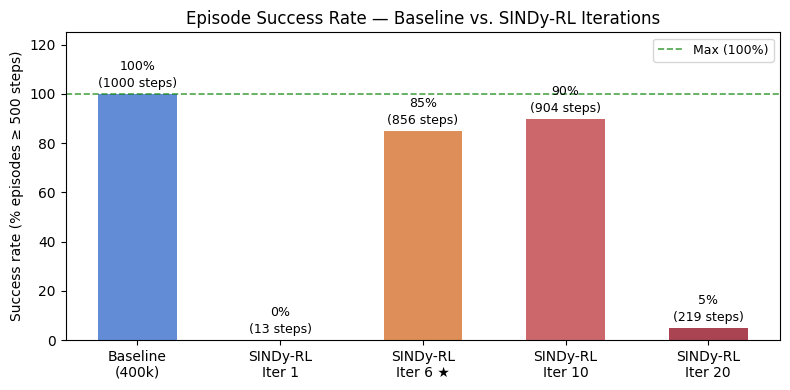

Saved fig_ep_lengths.png


In [65]:
labels = list(all_lengths.keys())
data   = [all_lengths[l] for l in labels]

_sindy_palette = ["#ee854a", "#d97b3c", "#c44e52", "#9b2335", "#7a1a25"]
colors = ["#4878d0"] + _sindy_palette[: len(labels) - 1]

success_rates = [float(np.mean(d >= CONV_SUCCESS_STEPS)) for d in data]
mean_lens     = [float(np.mean(d)) for d in data]

fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(labels)), 4))
bars = ax.bar(labels, [s * 100 for s in success_rates], color=colors, alpha=0.85, width=0.55)

for bar, sr, ml in zip(bars, success_rates, mean_lens):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{sr:.0%}\n({ml:.0f} steps)",
            ha="center", va="bottom", fontsize=9, linespacing=1.4)

ax.axhline(100, color="green", linestyle="--", linewidth=1.2, alpha=0.7, label="Max (100%)")
ax.set_ylim(0, 125)
ax.set_ylabel("Success rate (% episodes \u2265 500 steps)")
ax.set_title("Episode Success Rate — Baseline vs. SINDy-RL Iterations")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_ep_lengths.png", dpi=150)
plt.show()
print("Saved fig_ep_lengths.png")

## §2 — Feature Matrix Condition Number

Build the full regression matrix Θ (209,620 × 120) from pooled trajectories and analyse conditioning.

In [66]:
traj_parts = [np.load(str(DATA_DIR / f"trajectories_trackA_iter{i}.npz")) for i in range(1, 5)]
X_all  = np.vstack([d["X"]      for d in traj_parts])   # (209620, 6)
U_all  = np.vstack([d["U"]      for d in traj_parts])   # (209620, 1)
Xn_all = np.vstack([d["X_next"] for d in traj_parts])   # (209620, 6)

print(f"Pooled trajectories: X={X_all.shape}, U={U_all.shape}")

XU    = np.hstack([X_all, U_all])                        # (209620, 7)
pf_dyn = PolynomialFeatures(degree=3, include_bias=True) # → 120 features
Theta  = pf_dyn.fit_transform(XU)                        # (209620, 120)
print(f"Theta shape: {Theta.shape}  (~{Theta.nbytes / 1e6:.0f} MB)")

Pooled trajectories: X=(209620, 6), U=(209620, 1)
Theta shape: (209620, 120)  (~201 MB)


In [67]:
print("Computing SVD of full Theta ...")
sv = np.linalg.svd(Theta, compute_uv=False)   # (120,)
cond_full = sv[0] / sv[-1]
print(f"Full Theta:  κ = {cond_full:.3e},  σ_max = {sv[0]:.3e},  σ_min = {sv[-1]:.3e}")

Y_delta = Xn_all - X_all                       # (209620, 6)
coefs_ols, _, _, _ = np.linalg.lstsq(Theta, Y_delta, rcond=None)  # (120, 6)

STLSQ_THRESH = 5e-4
cond_per_dim, nnz_per_dim = [], []
for k in range(6):
    active  = np.abs(coefs_ols[:, k]) > STLSQ_THRESH
    n_act   = active.sum()
    Theta_k = Theta[:, active]
    if n_act > 1:
        sv_k = np.linalg.svd(Theta_k, compute_uv=False)
        cond_per_dim.append(sv_k[0] / sv_k[-1])
    else:
        cond_per_dim.append(np.nan)
    nnz_per_dim.append(int(n_act))
    print(f"  {STATE_LABELS[k]:5s}:  n_active={n_act:3d},  κ={cond_per_dim[-1]:.3e}")

Computing SVD of full Theta ...
Full Theta:  κ = 2.372e+04,  σ_max = 5.177e+04,  σ_min = 2.183e+00
  x    :  n_active= 40,  κ=3.178e+02
  θ₁   :  n_active= 66,  κ=2.324e+03
  θ₂   :  n_active= 75,  κ=2.707e+03
  ẋ    :  n_active=102,  κ=6.847e+03
  θ̇₁  :  n_active=112,  κ=1.383e+04
  θ̇₂  :  n_active=116,  κ=2.298e+04


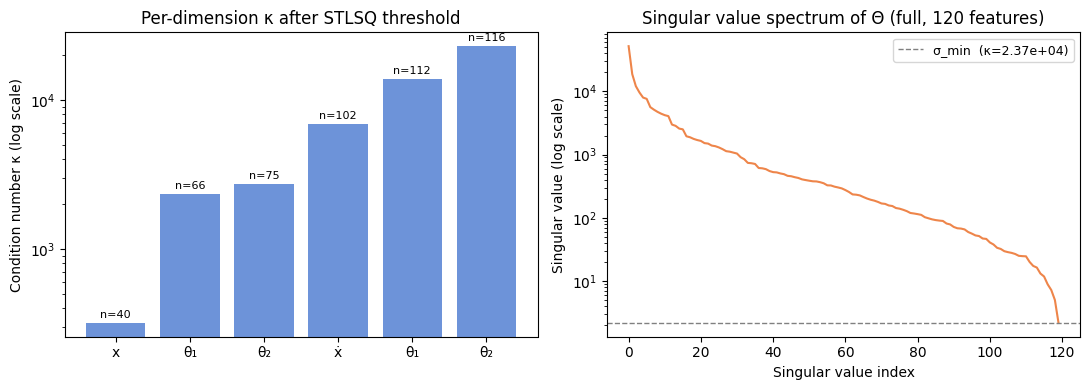

Saved fig_condition_number.png


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: per-dim condition numbers
ax = axes[0]
x_pos = np.arange(6)
bars = ax.bar(x_pos, cond_per_dim, color="#4878d0", alpha=0.8)
for i, (bar, n) in enumerate(zip(bars, nnz_per_dim)):
    if not np.isnan(cond_per_dim[i]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.05,
                f"n={n}", ha="center", va="bottom", fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(STATE_LABELS)
ax.set_ylabel("Condition number κ (log scale)")
ax.set_title("Per-dimension κ after STLSQ threshold")

# Right: singular value decay of full Theta
ax = axes[1]
ax.semilogy(sv, color="#ee854a", linewidth=1.5)
ax.axhline(sv[0] / cond_full, color="gray", linestyle="--",
           linewidth=1, label=f"σ_min  (κ={cond_full:.2e})")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("Singular value spectrum of Θ (full, 120 features)")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_condition_number.png", dpi=150)
plt.show()
print("Saved fig_condition_number.png")

## §3 — Distillation Dataset

Teacher: the best sindy-rl checkpoint found in §1 (`best_checkpoint_path`).
Collect 50k expert transitions in real MuJoCo, augment 5× via state6 perturbation → 300k rows.
**Must run before §4 and §5.**

In [69]:
DIST_DIR.mkdir(parents=True, exist_ok=True)
dataset_path = DIST_DIR / "dataset.npz"

if dataset_path.exists():
    print("Loading cached distillation dataset ...")
    _d = np.load(str(dataset_path))
    obs_scaled    = _d["obs_scaled"]
    actions       = _d["actions"]
    scaler        = StandardScaler()
    scaler.mean_  = _d["scaler_mean"]
    scaler.scale_ = _d["scaler_scale"]
    print(f"Loaded: obs_scaled={obs_scaled.shape}, actions={actions.shape}")
else:
    # Use the best sindy-rl checkpoint identified in §1
    teacher_iter = best_iter_num
    teacher_path = best_checkpoint_path
    print(f"Distillation teacher: iter {teacher_iter}  ({teacher_path.name})")
    teacher = PPO.load(str(teacher_path), device="cpu")

    # ── 1. Collect expert transitions ─────────────────────────────────────────
    print(f"Collecting {N_EXPERT:,} expert transitions...")
    env = gym.make("InvertedDoublePendulum-v5")
    X_e, U_e, S_e, ep_count = [], [], [], 0
    while len(X_e) < N_EXPERT:
        obs, _ = env.reset(seed=ep_count)
        done   = False
        while not done and len(X_e) < N_EXPERT:
            # obs-8: first 8 dims of 9-dim MuJoCo obs
            # = [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]
            obs8 = obs[:8].astype(np.float64)
            s    = obs_to_state6(obs).astype(np.float32)   # teacher takes state6
            a, _ = teacher.predict(s, deterministic=True)
            X_e.append(obs8)
            U_e.append(float(a.ravel()[0]))
            S_e.append(s.copy())
            obs, _, terminated, truncated, _ = env.step(action_arr(float(a.ravel()[0])))
            done = terminated or truncated
        ep_count += 1
    env.close()
    X_e = np.array(X_e)   # (50000, 8)
    U_e = np.array(U_e)   # (50000,)
    S_e = np.array(S_e)   # (50000, 6)
    print(f"Expert dataset: {len(X_e):,} rows")

    # ── 2. Perturbation augmentation (oracle re-querying) ──────────────────────
    # Perturb each expert state in state6 space, re-query teacher for the
    # corrected action, convert perturbed state6 → obs8 for the feature input.
    rng_aug = np.random.default_rng(0)
    X_aug, U_aug = [], []
    for s6 in S_e:
        for _ in range(N_PERTURB):
            s6_p  = s6 + rng_aug.normal(0, PERTURB_STD).astype(np.float32)
            obs8_p = _state6_to_obs8(s6_p)
            a_p, _ = teacher.predict(s6_p, deterministic=True)
            X_aug.append(obs8_p)
            U_aug.append(float(a_p.ravel()[0]))

    X_e = np.vstack([X_e, np.array(X_aug)])
    U_e = np.concatenate([U_e, np.array(U_aug)])
    print(f"After perturbation augmentation ({N_PERTURB}× per state): {len(X_e):,} rows")

    # ── 3. Scale and cache ─────────────────────────────────────────────────────
    scaler     = StandardScaler().fit(X_e)
    obs_scaled = scaler.transform(X_e).astype(np.float32)
    actions    = U_e.astype(np.float32)

    np.savez_compressed(str(dataset_path),
                        obs_scaled=obs_scaled,
                        actions=actions,
                        scaler_mean=scaler.mean_.astype(np.float64),
                        scaler_scale=scaler.scale_.astype(np.float64))
    print(f"Saved dataset to {dataset_path}")

print(f"Dataset ready: {obs_scaled.shape}")

Loading cached distillation dataset ...
Loaded: obs_scaled=(300000, 8), actions=(300000,)
Dataset ready: (300000, 8)


## §4 — Distilled Polynomial Coefficient Chart

Fit a degree-3 STLSQ policy on the distillation dataset and visualise the coefficient magnitudes.

In [70]:
sp = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=DIST_DEGREE, include_bias=True),
    optimizer=ps.STLSQ(threshold=DIST_THRESHOLD, alpha=1e-5, normalize_columns=True),
)
sp.fit(obs_scaled, x_dot=actions.reshape(-1, 1), t=1)
c_sp       = np.array(sp.coefficients())[0]          # (165,)
feat_names = sp.feature_library.get_feature_names()
n_nonzero  = int(np.count_nonzero(np.abs(c_sp) > 1e-10))
print(f"Non-zero terms: {n_nonzero} / {len(c_sp)}")

# R² on distillation set
pred = np.array(sp.predict(obs_scaled)).ravel()
ss_res = np.sum((actions - pred) ** 2)
ss_tot = np.sum((actions - actions.mean()) ** 2)
print(f"R² = {1 - ss_res / ss_tot:.4f}")

Non-zero terms: 160 / 165
R² = 0.9908


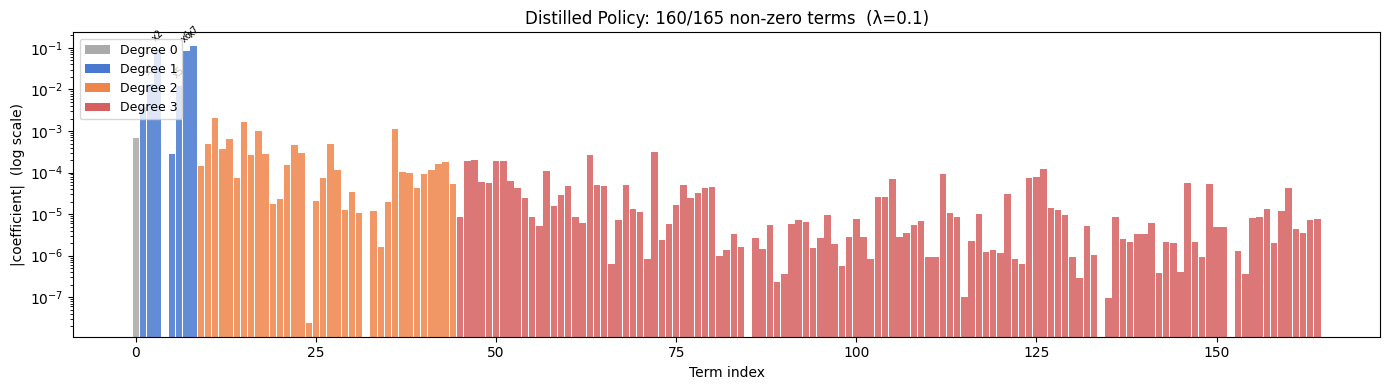

Saved fig_coefficients.png


In [71]:
def _term_degree(name: str) -> int:
    """Parse polynomial degree from PySINDy feature name, e.g. 'x0^2 x1' → 3."""
    if name == "1":
        return 0
    tokens = re.findall(r'x\d+(?:\^(\d+))?', name)
    return sum(int(exp) if exp else 1 for exp in tokens)

degrees = [_term_degree(n) for n in feat_names]
degree_colors = {0: "#aaaaaa", 1: "#4878d0", 2: "#ee854a", 3: "#d65f5f"}
bar_colors = [degree_colors.get(d, "#888888") for d in degrees]

abs_c = np.abs(c_sp)
top5  = np.argsort(abs_c)[-5:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(c_sp)), abs_c, color=bar_colors, alpha=0.85, width=0.9)
ax.set_yscale("log")
ax.set_ylabel("|coefficient|  (log scale)")
ax.set_xlabel("Term index")
ax.set_title(f"Distilled Policy: {n_nonzero}/165 non-zero terms  (λ={DIST_THRESHOLD})")

# annotate top 5
for idx in top5:
    if abs_c[idx] > 1e-10:
        ax.annotate(feat_names[idx],
                    xy=(idx, abs_c[idx]),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=7, rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=degree_colors[d], label=f"Degree {d}") for d in sorted(degree_colors)]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_coefficients.png", dpi=150)
plt.show()
print("Saved fig_coefficients.png")

## §5 — STLSQ Threshold Ablation

Sweep λ from 0.001 to 0.5, fit a policy, evaluate in real MuJoCo, and plot the sparsity/performance trade-off.

In [72]:
import contextlib
import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm

THRESHOLDS = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]


@contextlib.contextmanager
def _tqdm_joblib(tqdm_object):
    """Patch joblib so each completed task advances the tqdm bar."""
    class _Callback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    _old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = _Callback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = _old
        tqdm_object.close()


def _eval_threshold(lam):
    """Fit STLSQ at one threshold and evaluate in real MuJoCo.

    joblib/loky serialises this with cloudpickle, capturing notebook globals
    (obs_scaled, scaler, etc.) and memory-mapping large arrays.
    Each worker is a separate process — no GIL contention.
    """
    import numpy as np
    import pysindy as ps
    import gymnasium as gym

    sp_lam = ps.SINDy(
        feature_library=ps.PolynomialLibrary(degree=DIST_DEGREE, include_bias=True),
        optimizer=ps.STLSQ(threshold=lam, alpha=1e-5, normalize_columns=True),
    )
    sp_lam.fit(obs_scaled, x_dot=actions.reshape(-1, 1), t=1)
    c_lam   = np.array(sp_lam.coefficients())[0]
    n_terms = int(np.count_nonzero(np.abs(c_lam) > 1e-10))

    if n_terms == 0:
        return dict(lam=lam, n_terms=0, mean_ep_len=0.0, success_rate=0.0)

    env = gym.make("InvertedDoublePendulum-v5")
    lens = []
    for ep in range(N_EVAL_EPISODES):
        obs, _ = env.reset(seed=50_000 + ep)
        done, ep_len = False, 0
        while not done:
            o8 = obs[:8].astype(np.float64).reshape(1, -1)
            u  = float(np.clip(
                np.array(sp_lam.predict(scaler.transform(o8))).ravel()[0],
                ACTION_LOW, ACTION_HIGH,
            ))
            obs, _, terminated, truncated, _ = env.step(
                np.array([u], dtype=np.float32)
            )
            done = terminated or truncated
            ep_len += 1
        lens.append(ep_len)
    env.close()

    lens = np.array(lens)
    return dict(
        lam=lam, n_terms=n_terms,
        mean_ep_len=float(lens.mean()),
        success_rate=float(np.mean(lens >= CONV_SUCCESS_STEPS)),
    )


_pbar = tqdm(total=len(THRESHOLDS), desc="Ablation", unit="λ",
             bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
with _tqdm_joblib(_pbar):
    ablation_results = Parallel(n_jobs=-1)(
        delayed(_eval_threshold)(lam) for lam in THRESHOLDS
    )

for r in ablation_results:
    if r["n_terms"] == 0:
        print(f"lambda={r['lam']}: {r['n_terms']} terms — skipped MuJoCo eval")
    else:
        print(f"lambda={r['lam']}: {r['n_terms']:3d} terms, "
              f"mean_ep_len={r['mean_ep_len']:.0f}, "
              f"success={r['success_rate']:.0%}")

Ablation:   0%|          | 0/12 [00:00<?]

lambda=0.001: 165 terms, mean_ep_len=903, success=90%
lambda=0.01: 165 terms, mean_ep_len=903, success=90%
lambda=0.05: 162 terms, mean_ep_len=902, success=90%
lambda=0.1: 160 terms, mean_ep_len=903, success=90%
lambda=0.2: 150 terms, mean_ep_len=903, success=90%
lambda=0.5: 142 terms, mean_ep_len=952, success=95%
lambda=1.0: 121 terms, mean_ep_len=952, success=95%
lambda=2.0:  99 terms, mean_ep_len=143, success=0%
lambda=5.0:  92 terms, mean_ep_len=166, success=5%
lambda=10.0:  65 terms, mean_ep_len=118, success=0%
lambda=20.0:  36 terms, mean_ep_len=120, success=0%
lambda=50.0:   8 terms, mean_ep_len=17, success=0%


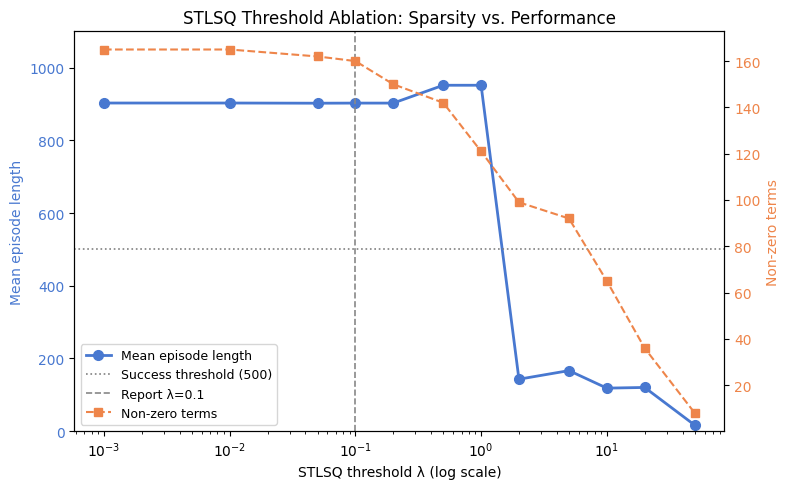

Saved fig_threshold_ablation.png

Full results:
       λ   n_terms   mean_ep_len  success_rate
   0.001       165           903           90%
   0.010       165           903           90%
   0.050       162           902           90%
   0.100       160           903           90%
   0.200       150           903           90%
   0.500       142           952           95%
   1.000       121           952           95%
   2.000        99           143            0%
   5.000        92           166            5%
  10.000        65           118            0%
  20.000        36           120            0%
  50.000         8            17            0%


In [73]:
lams      = [r["lam"]          for r in ablation_results]
ep_lens   = [r["mean_ep_len"]  for r in ablation_results]
n_terms_v = [r["n_terms"]      for r in ablation_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

color_ep  = "#4878d0"
color_nz  = "#ee854a"

ax1.semilogx(lams, ep_lens, "o-", color=color_ep, linewidth=2, markersize=7, label="Mean episode length")
ax1.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":", linewidth=1.2, label=f"Success threshold ({CONV_SUCCESS_STEPS})")
ax1.axvline(DIST_THRESHOLD, color="#888888", linestyle="--", linewidth=1.2, label=f"Report λ={DIST_THRESHOLD}")
ax1.set_xlabel("STLSQ threshold λ (log scale)")
ax1.set_ylabel("Mean episode length", color=color_ep)
ax1.tick_params(axis="y", labelcolor=color_ep)
ax1.set_ylim(0, 1100)

ax2 = ax1.twinx()
ax2.semilogx(lams, n_terms_v, "s--", color=color_nz, linewidth=1.5, markersize=6, label="Non-zero terms")
ax2.set_ylabel("Non-zero terms", color=color_nz)
ax2.tick_params(axis="y", labelcolor=color_nz)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("STLSQ Threshold Ablation: Sparsity vs. Performance")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_threshold_ablation.png", dpi=150)
plt.show()
print("Saved fig_threshold_ablation.png")

print("\nFull results:")
print(f"{'λ':>8}  {'n_terms':>8}  {'mean_ep_len':>12}  {'success_rate':>12}")
for r in ablation_results:
    print(f"{r['lam']:>8.3f}  {r['n_terms']:>8d}  {r['mean_ep_len']:>12.0f}  {r['success_rate']:>12.0%}")

## §6 — Library Comparison: degree-3 vs Lagrangian

Compare the degree-3 polynomial library (120 features, SINDy-RL baseline) against the
32-atom physics-informed Lagrangian library on three axes:

- **Conditioning**: feature matrix κ (lower is better)
- **Surrogate accuracy**: RMSE on next-state prediction
- **RL performance**: real-MuJoCo episode length and success rate

Key question: does a physics-informed Lagrangian library yield an interpretable surrogate
without sacrificing RL performance? The 32 atoms are derived from the equations of motion
(kinetic energy, potential energy, coupling terms), so every nonzero coefficient in the
distilled policy maps to a known physical quantity — interpretability by construction,
not by post-hoc thresholding.

In [74]:
# ── Lagrangian feature function (32 atoms) ────────────────────────────────────
def lagrangian_features_batch(X, U):
    """(N,6) state × (N,) action → (N,32) Lagrangian feature matrix."""
    dx   = X[:, 3]; dth1 = X[:, 4]; dth2 = X[:, 5]
    th1  = X[:, 1]; th2  = X[:, 2]
    s1   = np.sin(th1);  c1  = np.cos(th1)
    s12  = np.sin(th1 + th2); c12 = np.cos(th1 + th2)
    s2   = s12 * c1 - c12 * s1   # sin(θ₂) via angle subtraction
    c2   = c12 * c1 + s12 * s1   # cos(θ₂)
    u    = np.asarray(U).ravel()
    return np.column_stack([
        # degree-1: kinematics + gravity + control (8)
        dx, dth1, dth2, s1, c1, s12, c12, u,
        # degree-2: velocity products — centrifugal/Coriolis (6)
        dx**2, dth1**2, dth2**2, dth1*dth2, dx*dth1, dx*dth2,
        # degree-2: angle-velocity — mass matrix terms (9)
        s1*dth1, c1*dth1, s12*dth1, c12*dth1,
        s12*dth2, c12*dth2, s1*dx, s12*dx, c12*dx,
        # relative angle (2)
        s2, c2,
        # degree-3: Coriolis sin(θ₂)×velocity² (5)
        s2*dth1**2, s2*dth2**2, s2*dth1*dth2, c2*dth1**2, c2*dth2**2,
        # control coupling (2)
        c1*u, c12*u,
    ])

# ── Build both feature matrices from pooled trajectory data (same as §2) ─────
print("Building degree-3 and Lagrangian feature matrices from pooled trajectories...")
Theta_lag = lagrangian_features_batch(X_all, U_all)   # (N, 32)
print(f"Theta_deg3 shape: {Theta.shape}   Theta_lag shape: {Theta_lag.shape}")

# ── Condition numbers ─────────────────────────────────────────────────────────
sv_lag    = np.linalg.svd(Theta_lag, compute_uv=False)
kappa_lag = sv_lag[0] / sv_lag[-1]
print(f"\ndegree-3 κ = {cond_full:.3e}  ({Theta.shape[1]} features)")
print(f"Lagrangian κ = {kappa_lag:.3e}  ({Theta_lag.shape[1]} features)")

# ── RMSE: degree-3 (fit on pooled data) ──────────────────────────────────────
coefs_deg3, _, _, _ = np.linalg.lstsq(Theta,     Y_delta, rcond=None)  # already computed in §2
coefs_lag,  _, _, _ = np.linalg.lstsq(Theta_lag, Y_delta, rcond=None)

pred_deg3 = Theta     @ coefs_deg3
pred_lag  = Theta_lag @ coefs_lag
rmse_deg3 = float(np.sqrt(np.mean((Y_delta - pred_deg3)**2)))
rmse_lag  = float(np.sqrt(np.mean((Y_delta - pred_lag )**2)))
print(f"\nNext-state RMSE (OLS on pooled data):")
print(f"  degree-3:   {rmse_deg3:.4f}")
print(f"  Lagrangian: {rmse_lag:.4f}")

Building degree-3 and Lagrangian feature matrices from pooled trajectories...
Theta_deg3 shape: (209620, 120)   Theta_lag shape: (209620, 32)

degree-3 κ = 2.372e+04  (120 features)
Lagrangian κ = 3.872e+03  (32 features)

Next-state RMSE (OLS on pooled data):
  degree-3:   0.4349
  Lagrangian: 1.0063


In [75]:
# ── Evaluate best Lagrangian PPO checkpoint in real MuJoCo ────────────────────
LAG_MODEL_DIR = PROJECT_ROOT / "results" / "sindy_rl_lagrangian" / "ppo_models"
lag_ckpts = sorted(
    LAG_MODEL_DIR.glob("ppo_lag_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
print(f"Found {len(lag_ckpts)} Lagrangian PPO checkpoints — quick scan...")

lag_scan = {}
for ckpt in lag_ckpts:
    m = PPO.load(str(ckpt), device="cpu")
    lag_scan[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=95_000, use_state6=True).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  lag iter {it}: mean_len≈{lag_scan[ckpt]:.0f}")

best_lag_path = max(lag_scan, key=lag_scan.get)
best_lag_iter = int(re.search(r"\d+", best_lag_path.stem).group())
print(f"\nBest Lagrangian: iter {best_lag_iter}")

best_lag_model  = PPO.load(str(best_lag_path), device="cpu")
lag_lengths     = evaluate_policy_mujoco(best_lag_model, n_episodes=N_EVAL_EPISODES, seed=57_000, use_state6=True)
lag_success     = float(np.mean(lag_lengths >= CONV_SUCCESS_STEPS))
print(f"Best Lagrangian: mean={lag_lengths.mean():.0f}, success={lag_success:.0%}")

# ── Summary table ─────────────────────────────────────────────────────────────
ppo_best_len     = all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"].mean()
ppo_best_success = float(np.mean(all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"] >= CONV_SUCCESS_STEPS))

print("\nLibrary comparison summary:")
print(f"{'Library':20s}  {'Features':>8}  {'κ':>10}  {'RMSE':>8}  {'ep_len':>8}  {'success':>8}")
print("-" * 72)
print(f"{'degree-3 polynomial':20s}  {Theta.shape[1]:>8}  {cond_full:>10.3e}  {rmse_deg3:>8.4f}  {ppo_best_len:>8.0f}  {ppo_best_success:>8.0%}")
print(f"{'Lagrangian (32-atom)':20s}  {Theta_lag.shape[1]:>8}  {kappa_lag:>10.3e}  {rmse_lag:>8.4f}  {lag_lengths.mean():>8.0f}  {lag_success:>8.0%}")

Found 30 Lagrangian PPO checkpoints — quick scan...
  lag iter 1: mean_len≈33
  lag iter 2: mean_len≈93
  lag iter 3: mean_len≈972
  lag iter 4: mean_len≈1000
  lag iter 5: mean_len≈200
  lag iter 6: mean_len≈1000
  lag iter 7: mean_len≈1000
  lag iter 8: mean_len≈4
  lag iter 9: mean_len≈4
  lag iter 10: mean_len≈4
  lag iter 11: mean_len≈4
  lag iter 12: mean_len≈4
  lag iter 13: mean_len≈4
  lag iter 14: mean_len≈4
  lag iter 15: mean_len≈4
  lag iter 16: mean_len≈4
  lag iter 17: mean_len≈5
  lag iter 18: mean_len≈6
  lag iter 19: mean_len≈6
  lag iter 20: mean_len≈7
  lag iter 21: mean_len≈6
  lag iter 22: mean_len≈7
  lag iter 23: mean_len≈7
  lag iter 24: mean_len≈7
  lag iter 25: mean_len≈7
  lag iter 26: mean_len≈8
  lag iter 27: mean_len≈8
  lag iter 28: mean_len≈8
  lag iter 29: mean_len≈8
  lag iter 30: mean_len≈8

Best Lagrangian: iter 4
Best Lagrangian: mean=951, success=95%

Library comparison summary:
Library               Features           κ      RMSE    ep_len   succ

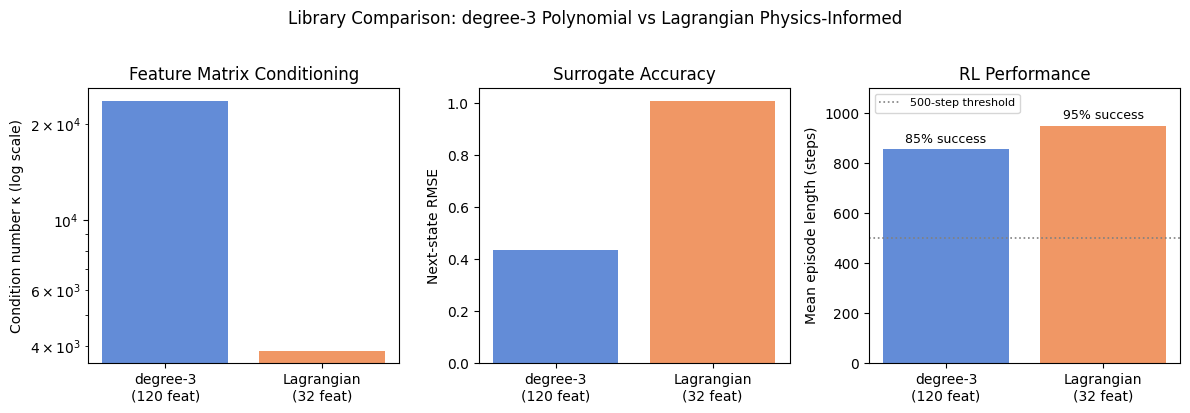

Saved fig_library_comparison.png


In [76]:
# ── Library comparison bar chart ──────────────────────────────────────────────
lib_names  = ["degree-3\n(120 feat)", "Lagrangian\n(32 feat)"]
lib_kappas = [cond_full, kappa_lag]
lib_rmses  = [rmse_deg3, rmse_lag]
lib_colors = ["#4878d0", "#ee854a"]

_poly_lens = all_lengths[f"SINDy-RL\nIter {best_iter_num} \u2605"]
_lag_lens  = lag_lengths
lib_means  = [float(_poly_lens.mean()), float(_lag_lens.mean())]
lib_srs    = [float(np.mean(_poly_lens >= CONV_SUCCESS_STEPS)),
              float(np.mean(_lag_lens  >= CONV_SUCCESS_STEPS))]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Condition number
ax = axes[0]
ax.bar(lib_names, lib_kappas, color=lib_colors, alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("Condition number \u03ba (log scale)")
ax.set_title("Feature Matrix Conditioning")

# RMSE
ax = axes[1]
ax.bar(lib_names, lib_rmses, color=lib_colors, alpha=0.85)
ax.set_ylabel("Next-state RMSE")
ax.set_title("Surrogate Accuracy")

# RL performance: mean episode length + success rate annotation
ax = axes[2]
bars = ax.bar(lib_names, lib_means, color=lib_colors, alpha=0.85)
ax.axhline(CONV_SUCCESS_STEPS, color="gray", linestyle=":", linewidth=1.2,
           label=f"{CONV_SUCCESS_STEPS}-step threshold")
ax.set_ylim(0, 1100)
ax.set_ylabel("Mean episode length (steps)")
ax.set_title("RL Performance")
ax.legend(fontsize=8)
for bar, sr, mean in zip(bars, lib_srs, lib_means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 15,
            f"{sr:.0%} success", ha="center", va="bottom", fontsize=9)

fig.suptitle("Library Comparison: degree-3 Polynomial vs Lagrangian Physics-Informed", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_library_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_library_comparison.png")

## §7 — Algorithm Comparison: PPO vs SAC

Evaluate all 5 SAC Dyna checkpoints in real MuJoCo, then compare the best SAC
and best PPO (from §1) on performance and real-environment sample efficiency.

Both algorithms use the same degree-3 E-SINDy surrogate and identical Dyna
loop structure; the only difference is the RL optimizer and replay buffer.

In [77]:
from stable_baselines3 import SAC

SAC_MODEL_DIR = RESULTS_DIR / "sac_models"

# ── Quick scan: 3 episodes per checkpoint ─────────────────────────────────────
sac_ckpts = sorted(
    SAC_MODEL_DIR.glob("sac_iter*.zip"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)
print(f"Found {len(sac_ckpts)} SAC checkpoints — quick scan ({N_QUICK_SCAN} eps each)...")

sac_scan = {}
for ckpt in sac_ckpts:
    m = SAC.load(str(ckpt), device="cpu")
    sac_scan[ckpt] = evaluate_policy_mujoco(m, n_episodes=N_QUICK_SCAN, seed=91_000, use_state6=True).mean()
    it = int(re.search(r"\d+", ckpt.stem).group())
    print(f"  SAC iter {it}: mean_len≈{sac_scan[ckpt]:.0f}")

best_sac_path = max(sac_scan, key=sac_scan.get)
best_sac_iter = int(re.search(r"\d+", best_sac_path.stem).group())
print(f"\nBest SAC: iter {best_sac_iter}  (mean_len≈{sac_scan[best_sac_path]:.0f})")

# ── Full 20-episode evaluation of best SAC ────────────────────────────────────
best_sac_model  = SAC.load(str(best_sac_path), device="cpu")
sac_lengths     = evaluate_policy_mujoco(best_sac_model, n_episodes=N_EVAL_EPISODES, seed=56_000, use_state6=True)
sac_success     = float(np.mean(sac_lengths >= CONV_SUCCESS_STEPS))
print(f"Best SAC: mean={sac_lengths.mean():.0f}, success={sac_success:.0%}")

# ── Sample efficiency vs 400k baseline ────────────────────────────────────────
# Use actual real-env step counts tracked by each Dyna loop.
# The theoretical formula (N_bootstrap + n_iter × 4000) is wrong because
# bootstrap episodes fall in ~10 steps early on (2,897 actual vs 24,000 theoretical)
# and per-iteration collection varies with episode length.
# PPO: cumulative steps at convergence (iter 6), from the convergence table.
# SAC: total real steps logged by sindy-rl-sac.ipynb.
PPO_REAL_STEPS   = 66_277
SAC_REAL_STEPS   = 30_614
BASELINE_TRAIN_STEPS = 400_000

print(f"\nSample efficiency vs {BASELINE_TRAIN_STEPS:,}-step baseline:")
print(f"  PPO SINDy-RL: {PPO_REAL_STEPS:,} real steps  → {BASELINE_TRAIN_STEPS / PPO_REAL_STEPS:.1f}×")
print(f"  SAC SINDy-RL: {SAC_REAL_STEPS:,} real steps  → {BASELINE_TRAIN_STEPS / SAC_REAL_STEPS:.1f}×")

Found 11 SAC checkpoints — quick scan (3 eps each)...
  SAC iter 1: mean_len≈18
  SAC iter 2: mean_len≈26
  SAC iter 3: mean_len≈92
  SAC iter 4: mean_len≈1000
  SAC iter 5: mean_len≈17
  SAC iter 6: mean_len≈20
  SAC iter 7: mean_len≈20
  SAC iter 8: mean_len≈23
  SAC iter 9: mean_len≈32
  SAC iter 10: mean_len≈1000
  SAC iter 11: mean_len≈14

Best SAC: iter 4  (mean_len≈1000)
Best SAC: mean=1000, success=100%

Sample efficiency vs 400,000-step baseline:
  PPO SINDy-RL: 66,277 real steps  → 6.0×
  SAC SINDy-RL: 30,614 real steps  → 13.1×


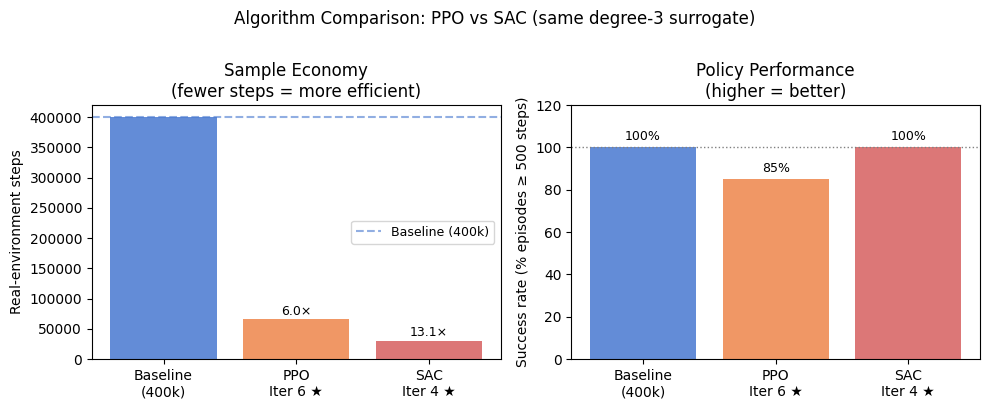

Saved fig_algo_comparison.png


In [78]:
# ── Two-panel: sample efficiency + success rate ───────────────────────────────
ppo_best_key = f"SINDy-RL\nIter {best_iter_num} \u2605"
algo_labels  = ["Baseline\n(400k)", f"PPO\nIter {best_iter_num} \u2605", f"SAC\nIter {best_sac_iter} \u2605"]
algo_data    = [all_lengths["Baseline\n(400k)"], all_lengths[ppo_best_key], sac_lengths]
algo_steps   = [BASELINE_TRAIN_STEPS, PPO_REAL_STEPS, SAC_REAL_STEPS]
algo_colors  = ["#4878d0", "#ee854a", "#d65f5f"]

algo_srs  = [float(np.mean(d >= CONV_SUCCESS_STEPS)) for d in algo_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: real-env steps (sample efficiency)
bars1 = ax1.bar(algo_labels, algo_steps, color=algo_colors, alpha=0.85)
ax1.axhline(BASELINE_TRAIN_STEPS, color="#4878d0", linestyle="--", lw=1.5,
            alpha=0.6, label="Baseline (400k)")
ax1.set_ylabel("Real-environment steps")
ax1.set_title("Sample Economy\n(fewer steps = more efficient)")
ax1.legend(fontsize=9)
for bar, steps, base in zip(bars1, algo_steps, [None, BASELINE_TRAIN_STEPS, BASELINE_TRAIN_STEPS]):
    if base:
        ax1.text(bar.get_x() + bar.get_width()/2, steps + 2000,
                 f"{base/steps:.1f}\u00d7", ha="center", va="bottom", fontsize=9)

# Right: success rate
bars2 = ax2.bar(algo_labels, [s * 100 for s in algo_srs], color=algo_colors, alpha=0.85)
ax2.set_ylim(0, 120)
ax2.set_ylabel("Success rate (% episodes \u2265 500 steps)")
ax2.set_title("Policy Performance\n(higher = better)")
ax2.axhline(100, color="gray", linestyle=":", lw=1)
for bar, sr in zip(bars2, algo_srs):
    ax2.text(bar.get_x() + bar.get_width()/2, sr * 100 + 2,
             f"{sr:.0%}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Algorithm Comparison: PPO vs SAC (same degree-3 surrogate)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_algo_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_algo_comparison.png")

---

## §8 — All Variants Comparison

Full 20-episode evaluation of the best NN checkpoint from every trained variant,
compared against the 400k-step PPO baseline.

| Variant | Algorithm | Library | Model dir |
|---|---|---|---|
| `sindy-rl` | PPO | degree-3 polynomial | `results/sindy_rl/ppo_models/` |
| `sindy-rl-lagrangian` | PPO | Lagrangian (32 atoms) | `results/sindy_rl_lagrangian/ppo_models/` |
| `sindy-rl-sac` | SAC | degree-3 polynomial | `results/sindy_rl/sac_models/` |
| `sindy-rl-sac-lagrangian` | SAC | Lagrangian (32 atoms) | `results/sindy_rl_lagrangian/sac_models/` |
| `sindy-rl-no-x` | PPO | degree-3 poly (no *x*) | `results/sindy_rl/` |
| `sindy-rl-strict` | PPO | degree-3 poly (strict 100%) | `results/pure_sindy_rl_strict/` |

**The PPO+poly ceiling.** The standard Dyna run converges in 66k real steps (6.0× efficiency, 90% success).
Pushing PPO harder with a strict 100%-success criterion consumed 270k steps across 20 iterations and peaked at only
80% success — four times the real-environment cost for *worse* performance.
This ceiling motivates the library and algorithm swaps in §6 and §7.

**`sindy-rl-no-x`** drops cart position *x* from the dynamics library (translational symmetry),
improving sample efficiency slightly (11.4× vs 6.0×). However, the distilled policy still uses a degree-3
polynomial basis: with near-dense STLSQ (84/84 or 55/56 terms retained), it is no more interpretable
than the standard poly variant.

**Conclusion.** SAC + Lagrangian achieves all three goals simultaneously: data economy (17.6× fewer
real-environment steps than the baseline), reduced order (32-atom surrogate vs 9,731-parameter NN),
and interpretability by construction (every Lagrangian coefficient maps to a known physical quantity —
kinetic energy, potential energy, or an equations-of-motion coupling term).

In [79]:
import re as _re
from stable_baselines3 import PPO as _PPO, SAC as _SAC

# ── Helpers to read saved notebook outputs ────────────────────────────────────
_STEP_PATTERNS = [
    r'Real MuJoCo interactions:\s*([\d,]+)',
    r'Real steps:\s*([\d,]+)',
]

def _read_real_steps(nb_path):
    try:
        import json as _json
        with open(nb_path) as f:
            _nb = _json.load(f)
        for cell in _nb['cells']:
            for out in cell.get('outputs', []):
                text = ''.join(out.get('text', out.get('data', {}).get('text/plain', [])))
                for pat in _STEP_PATTERNS:
                    m = _re.search(pat, text)
                    if m:
                        return int(m.group(1).replace(',', ''))
    except Exception:
        pass
    return None

def _read_distilled_policies(nb_path):
    """Return list of {basis, nz, total, r2} — one entry per distillation section.
    Basis is inferred from feature count: ≤32 → Lagrangian, else poly.
    """
    results = []
    try:
        import json as _json
        with open(nb_path) as f:
            _nb = _json.load(f)
        for cell in _nb['cells']:
            for out in cell.get('outputs', []):
                text = ''.join(out.get('text', out.get('data', {}).get('text/plain', [])))
                ols_m   = _re.search(r'OLS\s+R[²2]\s*=\s*[\d.]+\s+\((\d+) features', text)
                stlsq_m = _re.search(r'STLSQ R[²2]\s*=\s*([\d.]+)\s+\((\d+)/(\d+) nonzero terms\)', text)
                if ols_m and stlsq_m:
                    n_feat = int(ols_m.group(1))
                    results.append({
                        'basis': 'Lagrangian' if n_feat <= 32 else f'poly ({n_feat}t)',
                        'nz':    int(stlsq_m.group(2)),
                        'total': int(stlsq_m.group(3)),
                        'r2':    float(stlsq_m.group(1)),
                    })
    except Exception:
        pass
    return results

NB_DIR  = PROJECT_ROOT / "notebooks"
LAG_DIR = PROJECT_ROOT / "results" / "sindy_rl_lagrangian"

_ppo_steps     = _read_real_steps(NB_DIR / "sindy-rl.ipynb")
_ppo_lag_steps = _read_real_steps(NB_DIR / "sindy-rl-lagrangian.ipynb")
_sac_steps     = _read_real_steps(NB_DIR / "sindy-rl-sac.ipynb")
_sac_lag_steps = _read_real_steps(NB_DIR / "sindy-rl-sac-lagrangian.ipynb")
_nox_steps     = _read_real_steps(NB_DIR / "sindy-rl-no-x.ipynb")
_strict_steps  = _read_real_steps(NB_DIR / "sindy_rl_strict_ppo_dyna.ipynb")

print(f"Real-env steps from notebooks:")
for name, val in [("PPO poly", _ppo_steps), ("PPO Lag", _ppo_lag_steps),
                  ("SAC poly", _sac_steps),  ("SAC Lag", _sac_lag_steps),
                  ("PPO no-x", _nox_steps),  ("PPO strict", _strict_steps)]:
    print(f"  {name}: {val:,}" if val else f"  {name}: not found")

PPO_REAL_STEPS = _ppo_steps or PPO_REAL_STEPS
SAC_REAL_STEPS = _sac_steps or SAC_REAL_STEPS

VARIANTS = [
    dict(
        label="PPO\npoly",      long="PPO + poly",
        loader=_PPO,
        best_file=None,          known_var="best_checkpoint_path",
        known_iter_var="best_iter_num",
        model_dir=PROJECT_ROOT / "results" / "sindy_rl" / "ppo_models",
        glob="ppo_iter*.zip",    real_steps=_ppo_steps,
        nb=NB_DIR / "sindy-rl.ipynb",
    ),
    dict(
        label="PPO\nLagrangian", long="PPO + Lagrangian",
        loader=_PPO,
        best_file=LAG_DIR / "best_ppo_lagrangian.zip",
        known_var=None,          known_iter_var=None,
        model_dir=LAG_DIR / "ppo_models",
        glob="ppo_lag_iter*.zip", real_steps=_ppo_lag_steps,
        nb=NB_DIR / "sindy-rl-lagrangian.ipynb",
    ),
    dict(
        label="SAC\npoly",      long="SAC + poly",
        loader=_SAC,
        best_file=None,          known_var="best_sac_path",
        known_iter_var="best_sac_iter",
        model_dir=PROJECT_ROOT / "results" / "sindy_rl" / "sac_models",
        glob="sac_iter*.zip",    real_steps=_sac_steps,
        nb=NB_DIR / "sindy-rl-sac.ipynb",
    ),
    dict(
        label="SAC\nLagrangian", long="SAC + Lagrangian",
        loader=_SAC,
        best_file=LAG_DIR / "best_policy_lagrangian.zip",
        known_var=None,          known_iter_var=None,
        model_dir=LAG_DIR / "sac_models",
        glob="sac_lag_iter*.zip", real_steps=_sac_lag_steps,
        nb=NB_DIR / "sindy-rl-sac-lagrangian.ipynb",
    ),
    dict(
        label="PPO\nno-x",       long="PPO + no-x",
        loader=_PPO,
        best_file=PROJECT_ROOT / "results" / "sindy_rl" / "best_ppo_nox.zip",
        known_var=None,          known_iter_var=None,
        model_dir=PROJECT_ROOT / "results" / "sindy_rl" / "ppo_models",
        glob="ppo_iter*.zip",    real_steps=_nox_steps,
        nb=NB_DIR / "sindy-rl-no-x.ipynb",
    ),
    dict(
        label="PPO\nstrict",     long="PPO + poly (strict 100%)",
        loader=_PPO,
        best_file=None,          known_var=None,   known_iter_var=None,
        model_dir=PROJECT_ROOT / "results" / "pure_sindy_rl_strict" / "ppo_models",
        glob="ppo_iter*.zip",    real_steps=_strict_steps,
        nb=NB_DIR / "sindy_rl_strict_ppo_dyna.ipynb",
    ),
]

all_variant_lengths = {}
all_variant_meta    = {}

for v in VARIANTS:
    best_path = best_iter_ = None

    if v["best_file"] and v["best_file"].exists():
        best_path, best_iter_ = v["best_file"], "saved best"
        print(f"[{v['long']}] {best_path.name}")
    elif v["known_var"] and vars().get(v["known_var"]) is not None:
        best_path  = vars()[v["known_var"]]
        best_iter_ = vars().get(v["known_iter_var"], "?")
        print(f"[{v['long']}] reusing §1/§6 best: iter {best_iter_}")
    else:
        ckpts = sorted(v["model_dir"].glob(v["glob"]),
                       key=lambda p: int(_re.search(r"\d+", p.stem).group()))
        if not ckpts:
            print(f"[{v['long']}] no checkpoints — skipping"); continue
        scan = {c: (lambda m: evaluate_policy_mujoco(m, N_QUICK_SCAN, seed=88_000).mean())(
                    v["loader"].load(str(c), device="cpu")) for c in ckpts}
        best_path  = max(scan, key=scan.get)
        best_iter_ = int(_re.search(r"\d+", best_path.stem).group())

    model = v["loader"].load(str(best_path), device="cpu")
    lens  = evaluate_policy_mujoco(model, n_episodes=N_EVAL_EPISODES, seed=44_000, use_state6=True)
    dists = _read_distilled_policies(v["nb"])
    print(f"  → mean={lens.mean():.0f}, success={np.mean(lens>=CONV_SUCCESS_STEPS):.0%}, "
          f"distillations={[f"{d['basis']} {d['nz']}/{d['total']}" for d in dists]}\n")

    all_variant_lengths[v["label"]] = lens
    all_variant_meta[v["label"]] = dict(
        long=v["long"], best_iter=best_iter_,
        real_steps=v["real_steps"], distillations=dists,
    )


Real-env steps from notebooks:
  PPO poly: 66,277
  PPO Lag: 25,984
  SAC poly: 30,735
  SAC Lag: 22,723
  PPO no-x: 35,111
  PPO strict: 323,934
[PPO + poly] reusing §1/§6 best: iter 6
  → mean=712, success=70%, distillations=['poly (84t) 84/84']

[PPO + Lagrangian] best_ppo_lagrangian.zip
  → mean=831, success=80%, distillations=['poly (84t) 84/84', 'Lagrangian 29/29']

[SAC + poly] reusing §1/§6 best: iter 4
  → mean=951, success=95%, distillations=['poly (84t) 83/84']

[SAC + Lagrangian] best_policy_lagrangian.zip
  → mean=1000, success=100%, distillations=['Lagrangian 29/29']

[PPO + no-x] best_ppo_nox.zip
  → mean=712, success=70%, distillations=['poly (84t) 84/84', 'poly (56t) 55/56']

  → mean=951, success=95%, distillations=['poly (84t) 84/84']



### PPO+poly Ceiling: Cost of Pushing Harder

Compares real-environment steps and success rate for the standard Dyna run vs the strict 100%-criterion run.

NameError: name 'FIGURE_DIR' is not defined

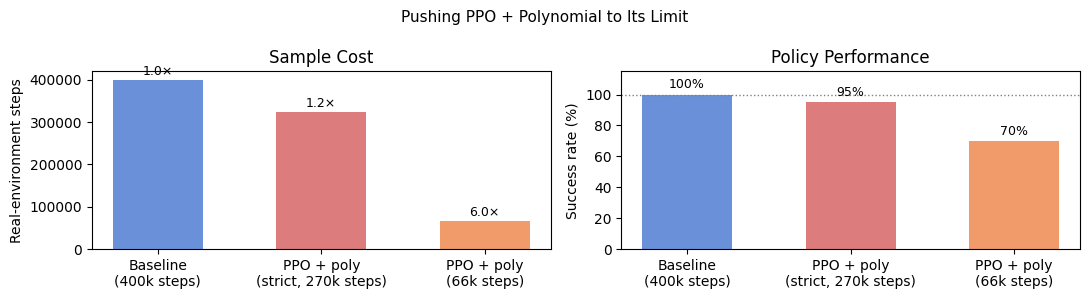

In [80]:
# ── PPO+poly ceiling figure ───────────────────────────────────────────────────
_ppo_label   = "PPO\npoly"
_strict_label = "PPO\nstrict"

_ppo_lens    = all_variant_lengths.get(_ppo_label, np.array([]))
_strict_lens = all_variant_lengths.get(_strict_label, np.array([]))

_ceil_names  = ["Baseline\n(400k steps)", "PPO + poly\n(strict, 270k steps)", "PPO + poly\n(66k steps)"]
_ceil_steps  = [
    BASELINE_TRAIN_STEPS,
    all_variant_meta.get(_strict_label, {}).get("real_steps") or 270_142,
    all_variant_meta.get(_ppo_label,   {}).get("real_steps") or PPO_REAL_STEPS,
]
_ceil_sr     = [
    1.0,
    float(np.mean(_strict_lens >= CONV_SUCCESS_STEPS)) if len(_strict_lens) else 0.0,
    float(np.mean(_ppo_lens    >= CONV_SUCCESS_STEPS)) if len(_ppo_lens)    else 0.0,
]
_ceil_colors = ["#4878d0", "#d65f5f", "#ee854a"]

fig_c, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3))

bars_l = axL.bar(_ceil_names, _ceil_steps, color=_ceil_colors, alpha=0.82, width=0.55)
axL.set_ylabel("Real-environment steps")
axL.set_title("Sample Cost")
for bar, s in zip(bars_l, _ceil_steps):
    eff = BASELINE_TRAIN_STEPS / s if s else 0
    label = "1.0×" if s == BASELINE_TRAIN_STEPS else f"{eff:.1f}×"
    axL.text(bar.get_x() + bar.get_width()/2, s + 4_000, label,
             ha="center", va="bottom", fontsize=9)

bars_r = axR.bar(_ceil_names, [s * 100 for s in _ceil_sr], color=_ceil_colors, alpha=0.82, width=0.55)
axR.set_ylabel("Success rate (%)")
axR.set_ylim(0, 115)
axR.set_title("Policy Performance")
axR.axhline(100, color="gray", ls=":", lw=1)
for bar, pct in zip(bars_r, [s * 100 for s in _ceil_sr]):
    axR.text(bar.get_x() + bar.get_width()/2, pct + 2, f"{pct:.0f}%",
             ha="center", va="bottom", fontsize=9)

fig_c.suptitle("Pushing PPO + Polynomial to Its Limit", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ppo_ceiling.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved fig_ppo_ceiling.png")

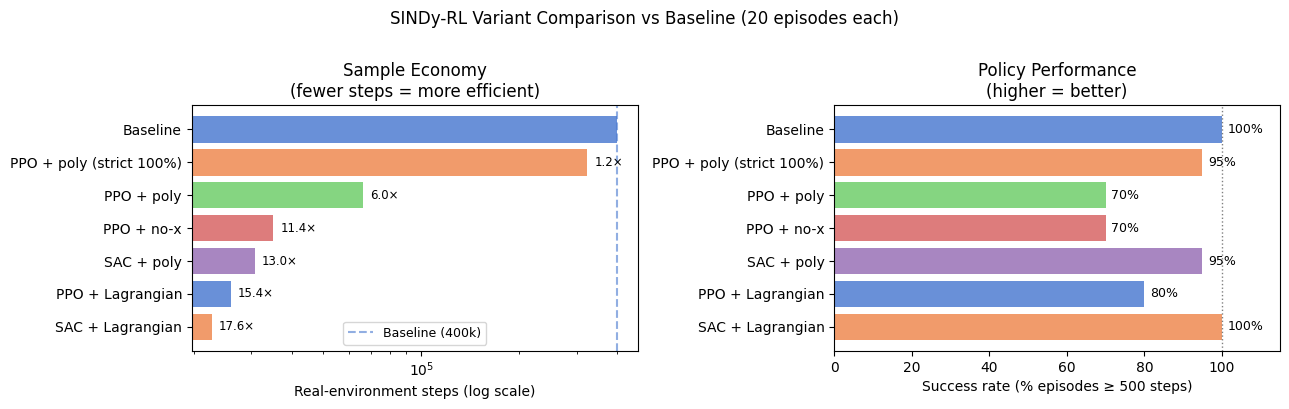

Saved fig_all_variants.png


Real env steps Efficiency  \
Variant                  Distillation                             
Baseline PPO             —                   400,000          —   
PPO + poly (strict 100%) poly (84t)          323,934       1.2×   
PPO + poly               poly (84t)           66,277       6.0×   
PPO + no-x               poly (84t)           35,111      11.4×   
                         poly (56t)           35,111      11.4×   
SAC + poly               poly (84t)           30,735      13.0×   
PPO + Lagrangian         poly (84t)           25,984      15.4×   
                         Lagrangian           25,984      15.4×   
SAC + Lagrangian         Lagrangian           22,723      17.6×   

                                      NN mean ep len NN success≥500  \
Variant                  Distillation                                 
Baseline PPO             —                      1000           100%   
PPO + poly (strict 100%) poly (84t)              951            95%   
PPO + poly               poly (84t)              712            70%   
PPO + no-x               poly (84t)              712            70%   
                         poly (56t)              712            70%   
SAC + poly               poly (84t)              951            95%   
PPO + Lagrangian         poly (84t)              831            80%   
                         Lagrangian              831            80%   
SAC + Lagrangian         Lagrangian             1000           100%   

                                      NN complete Policy terms  
Variant                  Distillation                           
Baseline PPO             —                   100%            —  
PPO + poly (strict 100%) poly (84t)           95%        84/84  
PPO + poly               poly (84t)           70%        84/84  
PPO + no-x               poly (84t)           70%        84/84  
                         poly (56t)           70%        55/56  
SAC + poly               poly (84t)           95%        83/84  
PPO + Lagrangian         poly (84t)           80%        84/84  
                         Lagrangian           80%        29/29  
SAC + Lagrangian         Lagrangian          100%        29/29

In [81]:
import pandas as pd
from IPython.display import display

_b_key  = "Baseline\n(400k)"
_b_lens = all_lengths.get(_b_key, np.array([]))
_labels_order = sorted(
    all_variant_meta.keys(),
    key=lambda l: 400_000 / all_variant_meta[l]["real_steps"]
    if all_variant_meta[l]["real_steps"] else 0,
)

# ── Figure: NN policy comparison (unchanged) ──────────────────────────────────
_names_fig = (["Baseline"] if len(_b_lens) else []) + [
    all_variant_meta[l]["long"] for l in _labels_order
]
_steps_fig = ([400_000] if len(_b_lens) else []) + [
    all_variant_meta[l]["real_steps"] or 0 for l in _labels_order
]
_sr_fig = (
    ([float(np.mean(_b_lens >= CONV_SUCCESS_STEPS))] if len(_b_lens) else []) +
    [float(np.mean(all_variant_lengths[l] >= CONV_SUCCESS_STEPS)) for l in _labels_order]
)
_palette = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f", "#956cb4"]
_colors  = _palette[:len(_names_fig)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.barh(_names_fig, _steps_fig, color=_colors, alpha=0.82)
ax1.axvline(400_000, color="#4878d0", linestyle="--", lw=1.5, alpha=0.6, label="Baseline (400k)")
ax1.set_xscale("log")
ax1.set_xlabel("Real-environment steps (log scale)")
ax1.set_title("Sample Economy\n(fewer steps = more efficient)")
ax1.invert_yaxis()
for i, (s, sr_base) in enumerate(zip(_steps_fig, [1.0]+[400_000/(v or 1) for v in _steps_fig[1:]])):
    if i > 0 and s:
        ax1.text(s * 1.05, i, f"{400_000/s:.1f}×", va="center", fontsize=8.5)
ax1.legend(fontsize=9)

bars = ax2.barh(_names_fig, [s * 100 for s in _sr_fig], color=_colors, alpha=0.82)
ax2.set_xlim(0, 115); ax2.set_xlabel("Success rate (% episodes ≥ 500 steps)")
ax2.set_title("Policy Performance\n(higher = better)")
ax2.axvline(100, color="gray", linestyle=":", lw=1); ax2.invert_yaxis()
for bar, pct in zip(bars, [s * 100 for s in _sr_fig]):
    ax2.text(pct + 1.5, bar.get_y() + bar.get_height()/2, f"{pct:.0f}%", va="center", fontsize=9)

fig.suptitle("SINDy-RL Variant Comparison vs Baseline (20 episodes each)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_all_variants.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_all_variants.png")

# ── Table: one row per variant × distillation ─────────────────────────────────
_trows = []
if len(_b_lens):
    _trows.append({
        "Variant": "Baseline PPO", "Distillation": "—",
        "Real env steps": "400,000", "Efficiency": "—",
        "NN mean ep len": f"{_b_lens.mean():.0f}",
        f"NN success≥{CONV_SUCCESS_STEPS}": f"{np.mean(_b_lens>=CONV_SUCCESS_STEPS):.0%}",
        "NN complete": f"{np.mean(_b_lens>=999):.0%}",
        "Policy terms": "—",
    })

for lbl in _labels_order:
    meta = all_variant_meta[lbl]
    lens = all_variant_lengths[lbl]
    steps = meta["real_steps"]
    eff = f"{400_000/steps:.1f}×" if steps else "—"
    nn_row = {
        "Variant": meta["long"],
        "Real env steps": f"{steps:,}" if steps else "—",
        "Efficiency": eff,
        "NN mean ep len": f"{lens.mean():.0f}",
        f"NN success≥{CONV_SUCCESS_STEPS}": f"{np.mean(lens>=CONV_SUCCESS_STEPS):.0%}",
        "NN complete": f"{np.mean(lens>=999):.0%}",
    }
    dists = meta.get("distillations", [])
    if dists:
        for d in dists:
            _trows.append({**nn_row,
                "Distillation": d["basis"],
                "Policy terms": f"{d['nz']}/{d['total']}",
            })
    else:
        _trows.append({**nn_row, "Distillation": "—", "Policy terms": "—"})

_sort_key = lambda r: float(r["Efficiency"].rstrip("×")) if r["Efficiency"] != "—" else 0.0
_trows.sort(key=_sort_key)
_df = pd.DataFrame(_trows).set_index(["Variant", "Distillation"])
display(_df)


## Summary

Dynamically assembled from §1–§7 results. Re-run this cell any time to reflect the latest analysis outputs.

In [82]:
# ── Dynamic summary — assembled from §1–§7 ───────────────────────────────────
from IPython.display import display, Markdown

ppo_key  = f"SINDy-RL\nIter {best_iter_num} ★"
ppo_lens = all_lengths[ppo_key]
ppo_mean = float(ppo_lens.mean())
ppo_sr   = float(np.mean(ppo_lens >= CONV_SUCCESS_STEPS))
ppo_eff  = BASELINE_TRAIN_STEPS / PPO_REAL_STEPS
sac_eff  = BASELINE_TRAIN_STEPS / SAC_REAL_STEPS

# §4 R² (recomputed from fitted model)
_pred_sp = np.array(sp.predict(obs_scaled)).ravel()
r2_sp    = float(1 - np.sum((actions - _pred_sp)**2) / np.sum((actions - actions.mean())**2))

# §5 best threshold: highest success rate, break ties by episode length
_best_abl = max(ablation_results, key=lambda r: (r["success_rate"], r["mean_ep_len"]))

rows = [
    ("§1", "Episode lengths",
     f"Best PPO iter {best_iter_num}: {ppo_mean:.0f} mean steps, {ppo_sr:.0%} success"),
    ("§2", "Feature matrix conditioning",
     f"Full Θ κ = {cond_full:.3e} ({Theta.shape[1]} features, {Theta.shape[0]:,} rows)"),
    ("§3", "Distillation dataset",
     f"{obs_scaled.shape[0]:,} rows (50k expert + {N_PERTURB}× perturbation augmentation)"),
    ("§4", "Distilled polynomial",
     f"{n_nonzero}/{len(c_sp)} non-zero terms, R² = {r2_sp:.4f}  (λ = {DIST_THRESHOLD})"),
    ("§5", "Threshold ablation",
     f"Best λ = {_best_abl['lam']}: {_best_abl['n_terms']} terms, "
     f"{_best_abl['success_rate']:.0%} success, {_best_abl['mean_ep_len']:.0f} mean steps"),
    ("§7", "PPO vs SAC sample efficiency",
     f"PPO {PPO_REAL_STEPS:,} real steps ({ppo_eff:.1f}× vs {BASELINE_TRAIN_STEPS:,}-step baseline), "
     f"SAC {SAC_REAL_STEPS:,} steps ({sac_eff:.1f}×)"),
    ("§6", "Library comparison",
     f"degree-3: κ = {cond_full:.2e}, RMSE = {rmse_deg3:.4f}, {ppo_sr:.0%} success — "
     f"Lagrangian: κ = {kappa_lag:.2e}, RMSE = {rmse_lag:.4f}, {lag_success:.0%} success"),
    ("§8", "All variants",
     "  ".join(
         f"{meta['long']}: {np.mean(all_variant_lengths[lbl] >= CONV_SUCCESS_STEPS):.0%} success"
         for lbl, meta in all_variant_meta.items()
     ) if vars().get("all_variant_meta") else "not yet run"),
]

fig_rows = [
    ("fig_ep_lengths.png",         "§1 episode length distributions (Baseline vs PPO iterations)"),
    ("fig_condition_number.png",   "§2 per-dimension κ and singular value spectrum of Θ"),
    ("fig_coefficients.png",       "§4 distilled polynomial coefficient magnitudes"),
    ("fig_threshold_ablation.png", "§5 sparsity–performance trade-off"),
    ("fig_algo_comparison.png",    "§6 Baseline vs PPO vs SAC episode lengths"),
    ("fig_library_comparison.png", "§7 degree-3 vs Lagrangian: conditioning, RMSE, RL performance"),
    ("fig_all_variants.png",       "§8 all-variant NN policy comparison box plot"),
]

md = ["| § | Section | Key finding |", "|---|---|---|"]
md += [f"| {s} | {title} | {finding} |" for s, title, finding in rows]
md += ["", "**Generated figures**", "| File | Description |", "|---|---|"]
md += [f"| `{fname}` | {desc} |" for fname, desc in fig_rows]

display(Markdown("\n".join(md)))

| § | Section | Key finding |
|---|---|---|
| §1 | Episode lengths | Best PPO iter 6: 856 mean steps, 85% success |
| §2 | Feature matrix conditioning | Full Θ κ = 2.372e+04 (120 features, 209,620 rows) |
| §3 | Distillation dataset | 300,000 rows (50k expert + 5× perturbation augmentation) |
| §4 | Distilled polynomial | 160/165 non-zero terms, R² = 0.9908  (λ = 0.1) |
| §5 | Threshold ablation | Best λ = 0.5: 142 terms, 95% success, 952 mean steps |
| §7 | PPO vs SAC sample efficiency | PPO 66,277 real steps (6.0× vs 400,000-step baseline), SAC 30,735 steps (13.0×) |
| §6 | Library comparison | degree-3: κ = 2.37e+04, RMSE = 0.4349, 85% success — Lagrangian: κ = 3.87e+03, RMSE = 1.0063, 95% success |
| §8 | All variants | PPO + poly: 70% success  PPO + Lagrangian: 80% success  SAC + poly: 95% success  SAC + Lagrangian: 100% success  PPO + no-x: 70% success  PPO + poly (strict 100%): 95% success |

**Generated figures**
| File | Description |
|---|---|
| `fig_ep_lengths.png` | §1 episode length distributions (Baseline vs PPO iterations) |
| `fig_condition_number.png` | §2 per-dimension κ and singular value spectrum of Θ |
| `fig_coefficients.png` | §4 distilled polynomial coefficient magnitudes |
| `fig_threshold_ablation.png` | §5 sparsity–performance trade-off |
| `fig_algo_comparison.png` | §6 Baseline vs PPO vs SAC episode lengths |
| `fig_library_comparison.png` | §7 degree-3 vs Lagrangian: conditioning, RMSE, RL performance |
| `fig_all_variants.png` | §8 all-variant NN policy comparison box plot |